In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

In [3]:
df = pd.read_csv(
    "../data/raw data/smart_home_energy_consumption_large.csv"
)

df.head()

,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


In [4]:
df.tail()

,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
99995,124,Microwave,0.42,09:56,2023-09-28,20.5,Summer,1
99996,184,Computer,0.71,12:48,2023-05-27,-5.4,Spring,2
99997,101,Dishwasher,0.25,05:45,2023-02-18,35.6,Winter,3
99998,423,Air Conditioning,2.69,12:39,2023-04-20,3.7,Spring,1
99999,429,Fridge,0.37,18:46,2023-02-27,36.0,Winter,5


In [5]:
df.shape

(100000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB


In [7]:
df.isnull().sum()

Home ID                     0
Appliance Type              0
Energy Consumption (kWh)    0
Time                        0
Date                        0
Outdoor Temperature (°C)    0
Season                      0
Household Size              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Remove duplicate rows (IMPORTANT)
df = df.drop_duplicates()

print("Duplicates removed. New shape:", df.shape)


Duplicates removed. New shape: (100000, 8)


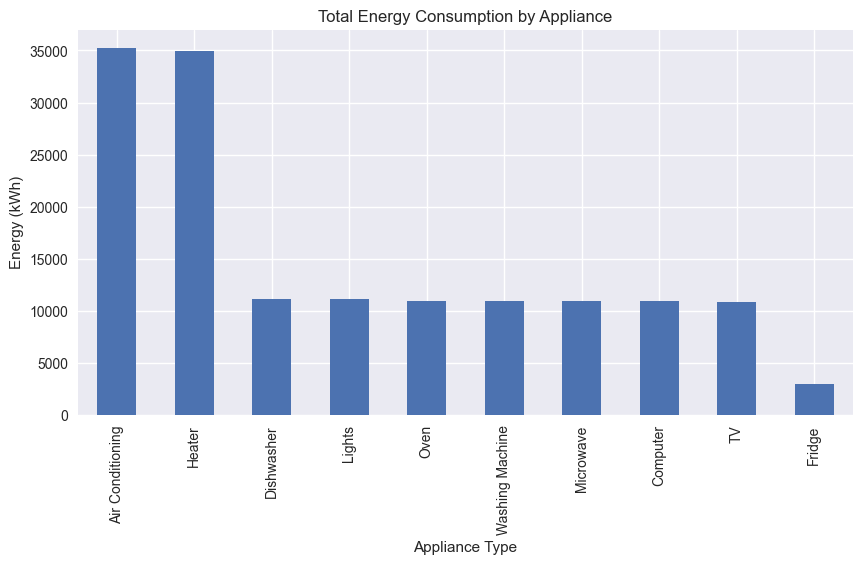

In [10]:
device_energy = (
    df.groupby("Appliance Type")["Energy Consumption (kWh)"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
device_energy.plot(kind="bar")
plt.title("Total Energy Consumption by Appliance")
plt.ylabel("Energy (kWh)")
plt.show()

In [11]:
# %%
# Create timestamp column
df['timestamp'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    errors='coerce'
)

# Remove invalid timestamps
df = df.dropna(subset=['timestamp'])

# Sort by timestamp (VERY IMPORTANT for time series)
df = df.sort_values('timestamp')

df[['Date', 'Time', 'timestamp']].head()


,Date,Time,timestamp
51495,2023-01-01,00:07,2023-01-01 00:07:00
26489,2023-01-01,00:13,2023-01-01 00:13:00
8690,2023-01-01,00:24,2023-01-01 00:24:00
33315,2023-01-01,00:26,2023-01-01 00:26:00
93438,2023-01-01,00:30,2023-01-01 00:30:00


In [12]:
df.isna().sum()

Home ID                     0
Appliance Type              0
Energy Consumption (kWh)    0
Time                        0
Date                        0
Outdoor Temperature (°C)    0
Season                      0
Household Size              0
timestamp                   0
dtype: int64

In [13]:
df = df.dropna(subset=['timestamp'])

In [14]:
# %%
# Drop original Date and Time columns
df = df.drop(['Date', 'Time'], axis=1)

# Set timestamp as index
df = df.set_index('timestamp')

# Sort index (CRITICAL for time series models)
df = df.sort_index()

print("Data time range:")
print(df.index.min(), "to", df.index.max())


Data time range:
2023-01-01 00:07:00 to 2024-01-01 23:53:00


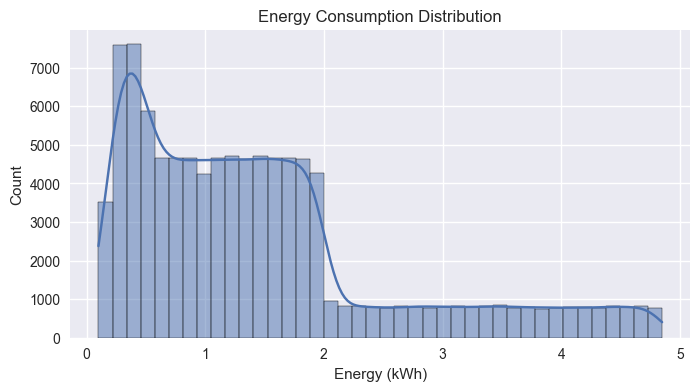

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(df['Energy Consumption (kWh)'], bins=40, kde=True)
plt.title("Energy Consumption Distribution")
plt.xlabel("Energy (kWh)")
plt.show()

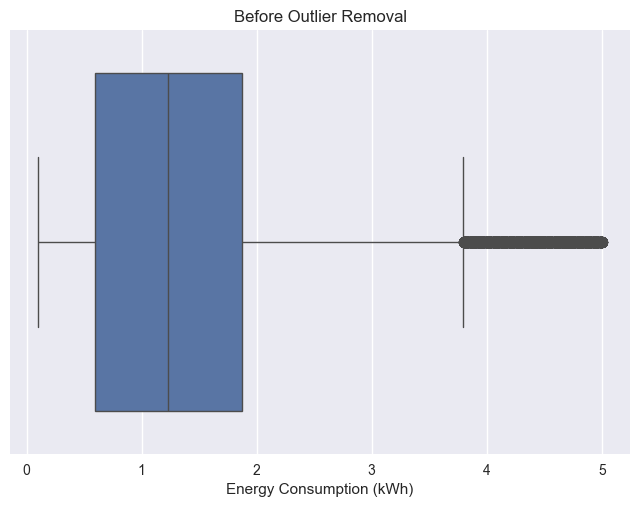

Outliers removed using 99th percentile


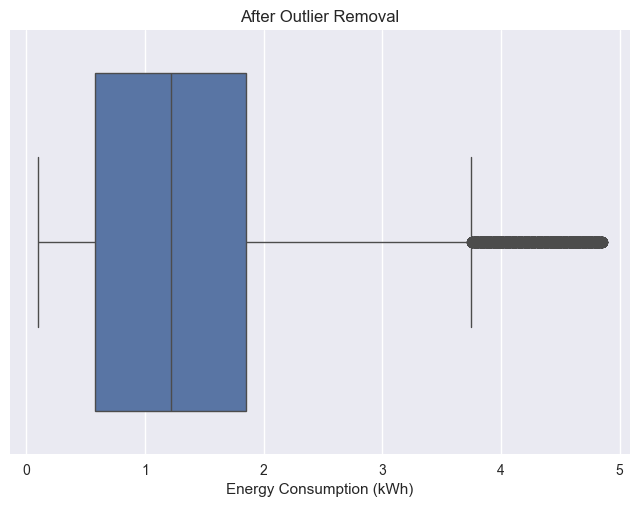

In [15]:
# %%
# Boxplot before removal
sns.boxplot(x=df['Energy Consumption (kWh)'])
plt.title("Before Outlier Removal")
plt.show()

# Remove top 1% outliers
upper_limit = df['Energy Consumption (kWh)'].quantile(0.99)

df = df[df['Energy Consumption (kWh)'] <= upper_limit]

print("Outliers removed using 99th percentile")

# Boxplot after removal
sns.boxplot(x=df['Energy Consumption (kWh)'])
plt.title("After Outlier Removal")
plt.show()


### Outlier Analysis

Outliers in energy consumption were analyzed using a boxplot visualization. 
The top 1% of values were filtered using the 99th percentile to ensure robustness 
against unusually high readings.

The boxplots before and after outlier removal show minimal visual change, indicating 
that the dataset does not contain significant extreme outliers. This suggests the data 
is already well-distributed and suitable for time-series modeling.

In [16]:
df['Appliance Type'].nunique()

10

In [17]:
# %%
# Resample data hourly per appliance
hourly_df = (
    df.groupby('Appliance Type')
      .resample('h')['Energy Consumption (kWh)']
      .sum()
      .reset_index()
)

print(hourly_df.head())
print("Shape:", hourly_df.shape)


     Appliance Type           timestamp  Energy Consumption (kWh)
0  Air Conditioning 2023-01-01 00:00:00                      4.42
1  Air Conditioning 2023-01-01 01:00:00                      7.61
2  Air Conditioning 2023-01-01 02:00:00                     14.80
3  Air Conditioning 2023-01-01 03:00:00                      4.19
4  Air Conditioning 2023-01-01 04:00:00                     10.68
Shape: (87828, 3)


In [19]:
ac_df = hourly_df[
    hourly_df['Appliance Type'] == 'Air Conditioning'
]

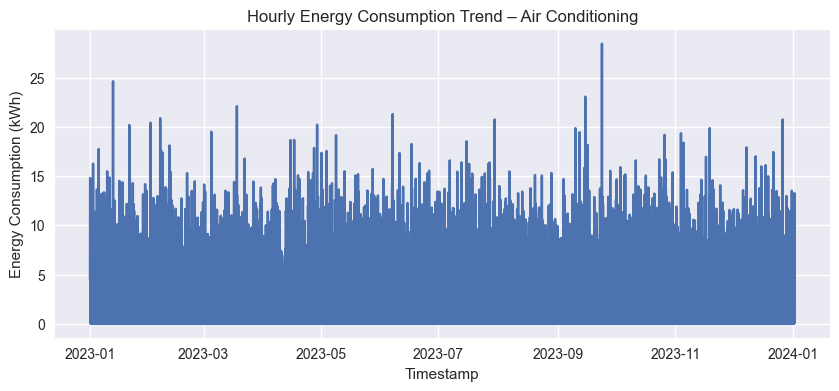

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(
    ac_df['timestamp'],
    ac_df['Energy Consumption (kWh)']
)
plt.title("Hourly Energy Consumption Trend – Air Conditioning")
plt.xlabel("Timestamp")
plt.ylabel("Energy Consumption (kWh)")
plt.show()

In [18]:
# %%
# Scale energy values for ML models
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

hourly_df['Energy Consumption (kWh)'] = scaler.fit_transform(
    hourly_df[['Energy Consumption (kWh)']]
)

print("Scaling completed.")

Scaling completed.


In [19]:
# %%
# Train-test split (80% train, 20% test)

train_size = int(len(hourly_df) * 0.8)

train_df = hourly_df[:train_size]
test_df = hourly_df[train_size:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)


Train size: (70262, 3)
Test size: (17566, 3)


### Hourly Energy Consumption Trend

This plot shows the hourly energy usage pattern for the Air Conditioning appliance.
It highlights daily usage cycles, peak demand periods, and idle durations, providing
useful insights into appliance-level energy behavior.

In [21]:
# %%
# Save processed datasets

hourly_df.to_csv(
    "../data/processed/hourly_device_energy_scaled.csv",
    index=False
)

train_df.to_csv(
    "../data/processed/train_energy_data.csv",
    index=False
)

test_df.to_csv(
    "../data/processed/test_energy_data.csv",
    index=False
)

print("Processed datasets saved successfully.")


Processed datasets saved successfully.


### Week 1–2 Summary

In this phase, the SmartHome Energy Monitoring dataset was explored and preprocessed. 
The data was cleaned by handling timestamps, removing invalid entries, and filtering 
extreme values. Appliance-level energy readings were resampled to an hourly frequency 
to create a structured time-series dataset. This processed dataset will serve as the 
input for feature engineering and baseline model development in the next phase.